In [1]:
!pip install pandas numpy scikit-learn joblib

In [2]:
import pandas as pd

path = "/content/drive/MyDrive/archive/CMaps/train_FD001.txt"

data = pd.read_csv(path, sep=" ", header=None)

data.head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [3]:
data = data.dropna(axis=1)

data.columns = ["unit","cycle"] + [f"sensor{i}" for i in range(1,25)]

data.head()

,unit,cycle,sensor1,sensor2,sensor3,sensor4,sensor5,sensor6,sensor7,sensor8,...,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,sensor22,sensor23,sensor24
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
max_cycle = data.groupby("unit")["cycle"].max()

data = data.merge(max_cycle.to_frame(name="max_cycle"), on="unit")

data["RUL"] = data["max_cycle"] - data["cycle"]

In [5]:
data["failure"] = data["RUL"].apply(lambda x: 1 if x < 30 else 0)

data["failure"].value_counts()

,count
failure,
0,17631
1,3000


In [6]:
features = ["sensor2","sensor3","sensor4","sensor7","sensor11","sensor12","sensor15"]

X = data[features]

y = data["failure"]

In [7]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=120,
    max_depth=12,
    random_state=42
)

model.fit(X_train,y_train)

RandomForestClassifier(max_depth=12, n_estimators=120, random_state=42)

In [9]:
from sklearn.metrics import accuracy_score,classification_report

pred = model.predict(X_test)

accuracy = accuracy_score(y_test,pred)

print("Accuracy:",accuracy)

print(classification_report(y_test,pred))

Accuracy: 0.9563847831354495
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      3559
           1       0.88      0.79      0.83       568

    accuracy                           0.96      4127
   macro avg       0.92      0.89      0.90      4127
weighted avg       0.96      0.96      0.96      4127



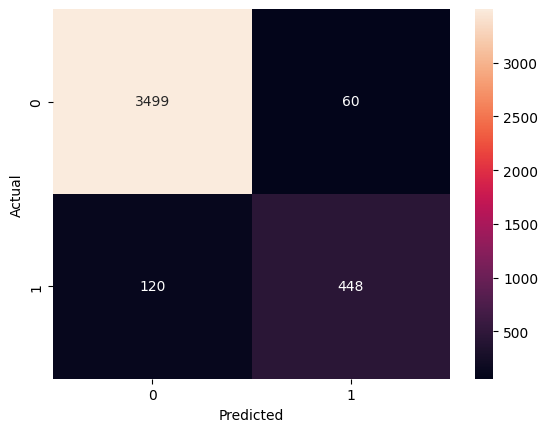

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
import joblib

model_path = "/content/drive/MyDrive/predictive_model.pkl"

joblib.dump(model,model_path)

print("Model saved!")

Model saved!


In [12]:
stream_data = data.sample(500)

stream_data.to_csv(
"/content/drive/MyDrive/sensor_stream.csv",
index=False
)